# Week 3 - Univariate Analysis
Please run the cells of the notebook as you get to them while reading.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

## 1. Lesson: Bar charts and univariate graphs

Let's make a dataset (in this case, just a series) which is weighted to have more small values than large values. By squaring a random number between 0 and 1, we ensure that half (those whose initial value is below 0.5) are below 0.25, while the other half are between 0.25 and 1. This means that most of the values are small, and it's more interesting than analyzing a perfectly uniform dataset. This kind of trick - transforming one random variable to get another - can generate a variety of random datasets for you. We then multiply by 100 to get a number between 0 and 100.

In [2]:
np.random.seed(0)
lesson_series = np.round(np.random.random(size = 1000)**2 * 100, 2)
lesson_series[0:10] # check the first ten values.  Are they mostly on the small side?

array([30.12, 51.15, 36.33, 29.69, 17.95, 41.72, 19.15, 79.53, 92.86,
       14.7 ])

In [3]:
import seaborn as sns

In the plot below, you can see a histogram of the values in the series. For some reason, it decided to have exactly 11 bins (we allowed it to choose the number of bins.) Most values - about 300 of them - are between 0 and 9, and the next most likely bin is between 9 and 18. Since there are 1000 values, the total of the bars should be 1000.

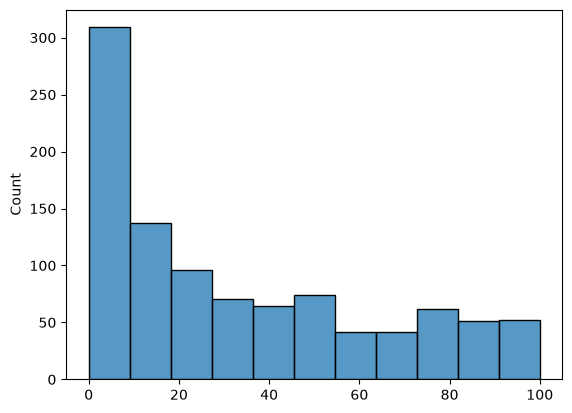

In [4]:
sns.histplot(lesson_series)
plt.show()

There are 11 bins or bars, a number which by default is chosen by seaborn. We can reproduce this manually to (hopefully) see the same values as numbers. I'm not sure that this second histogram is guaranteed to be exactly the same, but it looks the same to me:

In [5]:
np.histogram(lesson_series, bins = 11)[0]

array([309, 137,  96,  71,  64,  74,  42,  42,  62,  51,  52])

What happens if we override seaborn and choose the number of bins ourselves? We could choose a much larger number of bins:

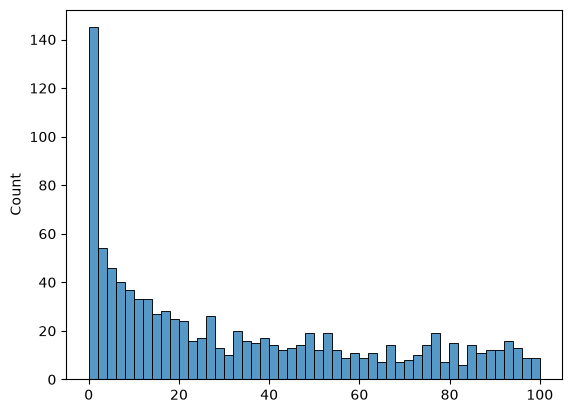

In [6]:
sns.histplot(lesson_series, bins = 50)
plt.show()

One disadvantage of this 50 bin picture is that the outliers are worse. That is, the graph wobbles up and down a bit more randomly. That's because there are fewer values in each bin, so there's more of a role for chance to take effect. If we had many more data points and/or fewer bins, we could get rid of this wobble.

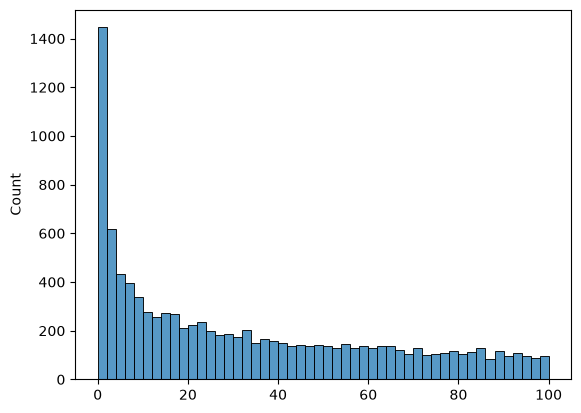

In [7]:
lesson_series_2 = np.round(np.random.random(size = 10000)**2 * 100, 2)
sns.histplot(lesson_series_2, bins = 50)
plt.show()

Here you can see that because the number of bins is the same as in the second graph above, but for more data, the histogram is a smoother graph. Why does more data make for a smoother graph? Something for you to think about. I said it's because a larger number of data points in each bin reduces the role of chance - but why is that?

> **My answer:** Each bar's height is a count, and the random "noise" in a count grows roughly like the square root of the count, while the count itself grows linearly. If a bin expects 100 values, it typically varies by about ±10 (10%); if it expects 10,000 values, it varies by about ±100 (only 1%). So with more data, the random wobble becomes a smaller and smaller fraction of each bar's height, and the shape looks smoother.

Here is a KDE (Kernel Density Estimate) plot. It's just the same histogram, but drawn smoothly. The KDE plot doesn't have a "number of bins." It's always drawn the same way. In this case, because of the smoothness of the curve, it seems that x-values less then zero and above 100 are still plotted, even though there were no such values in the dataset. This seems like a drawback of the KDE plot, especially if the viewer is unprepared for this aspect of the plot.

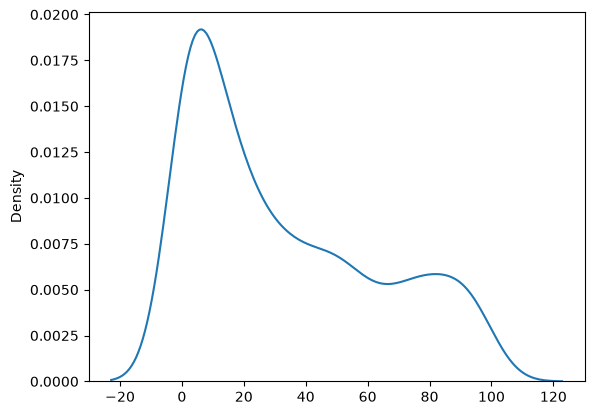

In [8]:
sns.kdeplot(lesson_series)
plt.show()

We could also draw a box plot. This time, to construct the data I used a fourth power rather than squaring, with only 100 data points, so that the points are even more concentrated toward the small numbers. It turns out that this will create a more interesting boxplot. The top and bottom edges of the box are the 75th and 25th percentile, respectively, and the top and bottom "whiskers" show a larger range which is a multiple of 1.5 times the the box height. (The bottom whisker cannot be see because it's pushed against the bottom of the graph.) The filled-in box shows that half of the values are between about 0 and 30 on the y-axis. Is that what you'd expect? The 25th and 75th percentile of the original uniform random variable are at 0.25 and 0.75. Taken to the fourth power and multiplied by 100 (remember, that's how we constructed our sample), that's 0.25\*\*4 \* 100 = 0.4 and 0.75\*\*4 \* 100 = 32. It's plausible that those are the height of the bottom and top of the box. We can see that a small number of samples are above the top whisker; they are shown as individual dots.

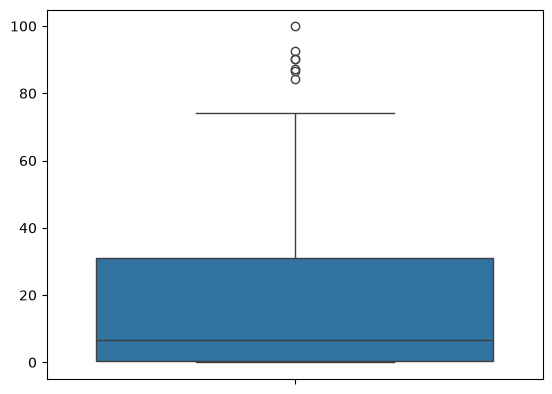

In [9]:
lesson_series_3 = np.round(np.random.random(size = 100)**4 * 100, 2)
sns.boxplot(lesson_series_3)
plt.show()

If we go back to the original lesson_series with the squared values, there will be two whiskers, because it isn't so strongly weighted toward small values:

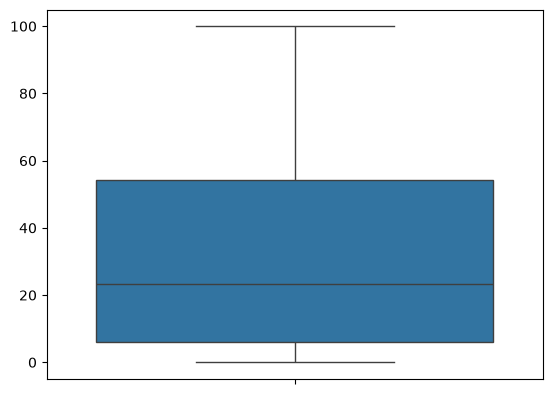

In [10]:
sns.boxplot(lesson_series)
plt.show()

Going back to the fourth power series, another histogram variant is the violin plot. This simply combines a kde plot (turned on its side and forming two side of the violin) with a boxplot:

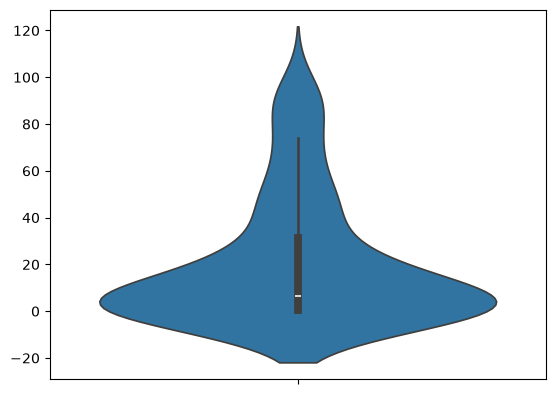

In [11]:
sns.violinplot(lesson_series_3)
plt.show()

Finally, a swarm plot shows the histogram (turned on its side and doubled, as with the violin plot) but showing each individual point.

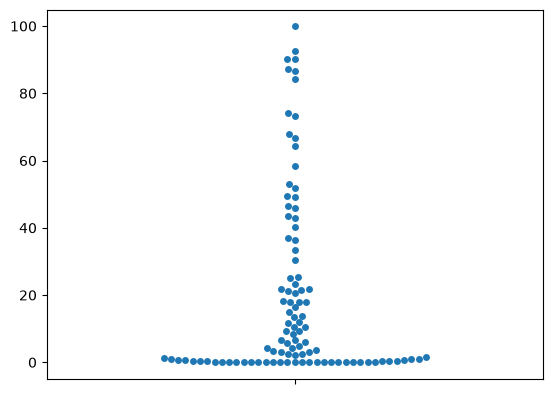

In [12]:
sns.swarmplot(lesson_series_3)
plt.show()

## 2. Weekly graph question
Below are a histogram and table representation of the same data. A species of bird is being analyzed, and each individual's body length in inches has been measured.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [13]:
np.random.seed(0)
num_data = 10000
data = np.random.normal(size = num_data) + 6
df = pd.DataFrame(data.T, columns = ["data"])
histnums = np.histogram(df["data"])
histcounts = histnums[0]
histmins = histnums[1][0:-1]
histmaxes = histnums[1][1:]
pd.DataFrame(np.array([histcounts, histmins, histmaxes]).T, columns = ["count", "minval", "maxval"])

,count,minval,maxval
0,10.0,2.259899,3.014075
1,110.0,3.014075,3.768252
2,579.0,3.768252,4.522428
3,1710.0,4.522428,5.276604
4,2833.0,5.276604,6.030780
5,2688.0,6.030780,6.784956
6,1479.0,6.784956,7.539132
7,487.0,7.539132,8.293308
8,97.0,8.293308,9.047484
9,7.0,9.047484,9.801660


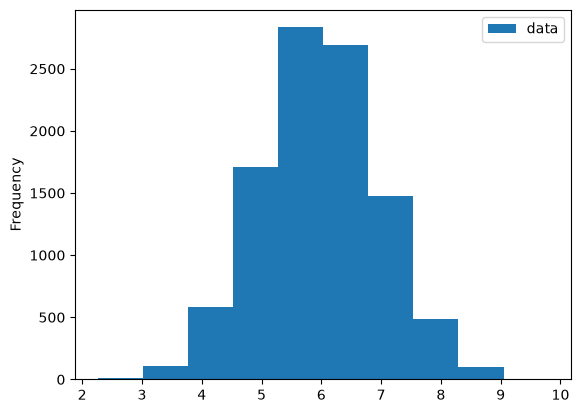

In [14]:
df.plot.hist()
plt.show()

### My answer

**Table:**
- *Pros:* Shows exact counts and exact bin boundaries, so a reader can look up precise numbers (e.g. exactly how many birds were between 5.4 and 6.0 inches).
- *Cons:* It's hard to see the overall shape of the distribution at a glance. The bin edges have many decimal places, and the counts are shown as floats (e.g. `3.0`, `1532.0`), which adds clutter. There are no units.

**Histogram:**
- *Pros:* The shape is obvious immediately: the data is symmetric and bell-shaped (normal), centered around 6 inches, with few birds below 3 or above 9.
- *Cons:* Exact values are hard to read. The default pandas version has a meaningless axis label ("Frequency"), a legend that just says "data", no title, no units, and the bin edges don't fall on round numbers.

**Which I'd choose:** The histogram, because most audiences care about the shape of the distribution (typical size and spread) more than exact counts. The table could go in an appendix for anyone who needs exact numbers.

**Improvements:** Add a title and axis labels with units ("Body length (inches)", "Number of birds"), remove the legend, use bins with round-number edges (e.g. every 0.5 inch), add edge lines between bars, possibly mark the mean with a vertical line, and remove the top/right borders. For the table, round the bin edges, show counts as integers, and possibly add a percentage column. Both improved versions are below.

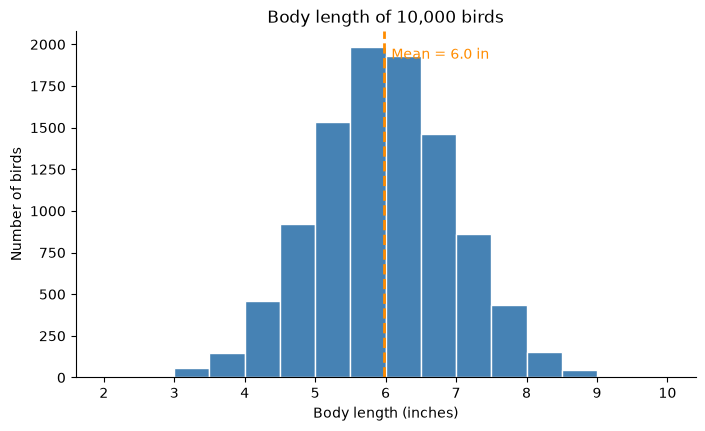

In [15]:
# Improved histogram
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(np.floor(df["data"].min()), np.ceil(df["data"].max()) + 0.5, 0.5)
ax.hist(df["data"], bins=bins, color="steelblue", edgecolor="white")
mean_len = df["data"].mean()
ax.axvline(mean_len, color="darkorange", linestyle="--", linewidth=2)
ax.text(mean_len + 0.1, ax.get_ylim()[1] * 0.92, f"Mean = {mean_len:.1f} in", color="darkorange")
ax.set_title("Body length of 10,000 birds")
ax.set_xlabel("Body length (inches)")
ax.set_ylabel("Number of birds")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [16]:
# Improved table
table = pd.DataFrame({
    "Length range (in)": [f"{lo:.1f} to {hi:.1f}" for lo, hi in zip(histmins, histmaxes)],
    "Count": histcounts.astype(int),
    "Percent": np.round(histcounts / histcounts.sum() * 100, 1),
})
table

,Length range (in),Count,Percent
0,2.3 to 3.0,10,0.1
1,3.0 to 3.8,110,1.1
2,3.8 to 4.5,579,5.8
3,4.5 to 5.3,1710,17.1
4,5.3 to 6.0,2833,28.3
5,6.0 to 6.8,2688,26.9
6,6.8 to 7.5,1479,14.8
7,7.5 to 8.3,487,4.9
8,8.3 to 9.0,97,1.0
9,9.0 to 9.8,7,0.1


## 3. Homework - Amusement Park Rides
Now let's imagine we have some data about how many times different visitors to an amusement park used each ride, as well as how much money they spend at the amusement park. Each sample represents a single visit by a single visitor on a given date.

In [17]:
num_visits = 10000
np.random.seed(0)
df = pd.DataFrame(columns = ["VisitDate"])
start = datetime(2010, 1, 1)
end = datetime(2024, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size = num_visits)
s = start + pd.to_timedelta(random_days, unit='D')
s = s.sort_values()
df["VisitDate"] = s
df["IsAdult"] = np.random.choice([True, True, False], size = num_visits)
df["MartianRide"] = np.random.choice([0] * 8 + [1] * 3 + [2] * 3 + [3] * 1 + [10], size = num_visits) * df["IsAdult"]
df["TeacupRide"] = np.random.choice([0] * 2 + [1] * 5 + [2] * 3 + [5] * 2, size = num_visits) * ~df["IsAdult"]
df["RiverRide"] = np.random.choice([0] * 8 + [1] * 3 + [2] * 2, size = num_visits) * df["IsAdult"] + np.random.randint(1, 5, size = num_visits) * ~df["IsAdult"]
df["MoneySpent"] = np.round(np.random.random(size = num_visits)**2 * 100, 2)
df.iloc[0:5]

,VisitDate,IsAdult,MartianRide,TeacupRide,RiverRide,MoneySpent
0,2010-01-01,False,0,1,4,10.30
1,2010-01-01,True,3,0,0,38.77
2,2010-01-01,True,0,0,0,79.34
3,2010-01-01,True,0,0,1,87.84
4,2010-01-02,False,0,1,2,18.65


In [18]:
# A list of the ride columns, used throughout the homework
rides = ["MartianRide", "TeacupRide", "RiverRide"]

### 3.1 Mean, median, and mode for how many times visitors rode each ride

In [19]:
summary = pd.DataFrame({
    "mean": df[rides].mean(),
    "median": df[rides].median(),
    "mode": df[rides].mode().iloc[0],   # mode() returns a DataFrame; the first row is the most common value
})
summary

,mean,median,mode
MartianRide,0.9073,0.0,0
TeacupRide,0.5862,0.0,0
RiverRide,1.2007,1.0,0


### 3.2 Using groupby() to find the mean, median, and mode for each ride on each day

In [20]:
daily = df.groupby("VisitDate")[rides]

daily_mean = daily.mean()
daily_mean.head()

,MartianRide,TeacupRide,RiverRide
VisitDate,,,
2010-01-01,0.75,0.25,1.25
2010-01-02,0.00,1.00,2.00
2010-01-03,0.00,1.50,1.25
2010-01-04,0.00,0.00,1.00
2010-01-05,0.50,0.00,0.00


In [21]:
daily_median = daily.median()
daily_median.head()

,MartianRide,TeacupRide,RiverRide
VisitDate,,,
2010-01-01,0.0,0.0,0.5
2010-01-02,0.0,1.0,2.0
2010-01-03,0.0,0.5,0.5
2010-01-04,0.0,0.0,1.0
2010-01-05,0.5,0.0,0.0


In [22]:
# There is no built-in groupby .mode(), so we apply Series.mode() to each group
# and take the first value (the smallest one if there is a tie).
daily_mode = daily.agg(lambda x: x.mode().iloc[0])
daily_mode.head()

,MartianRide,TeacupRide,RiverRide
VisitDate,,,
2010-01-01,0,0,0
2010-01-02,0,1,2
2010-01-03,0,0,0
2010-01-04,0,0,1
2010-01-05,0,0,0


### 3.3 Standard deviation and variance of the count for each ride

In [23]:
pd.DataFrame({
    "std": df[rides].std(),
    "variance": df[rides].var(),
})

,std,variance
MartianRide,2.077339,4.315338
TeacupRide,1.232851,1.519922
RiverRide,1.295757,1.678987


### 3.4 90th percentile count for each ride
The pandas function is `quantile()` (a quantile of 0.9 is the 90th percentile).

In [24]:
df[rides].quantile(0.9)

MartianRide    2.0
TeacupRide     2.0
RiverRide      3.0
Name: 0.9, dtype: float64

### 3.5 Histograms of the daily ride count
First we add a column for each visitor's total number of rides (all three rides together). Then, grouping by day, we take the **total** rides per day and, separately, the **mean** rides per visitor per day.

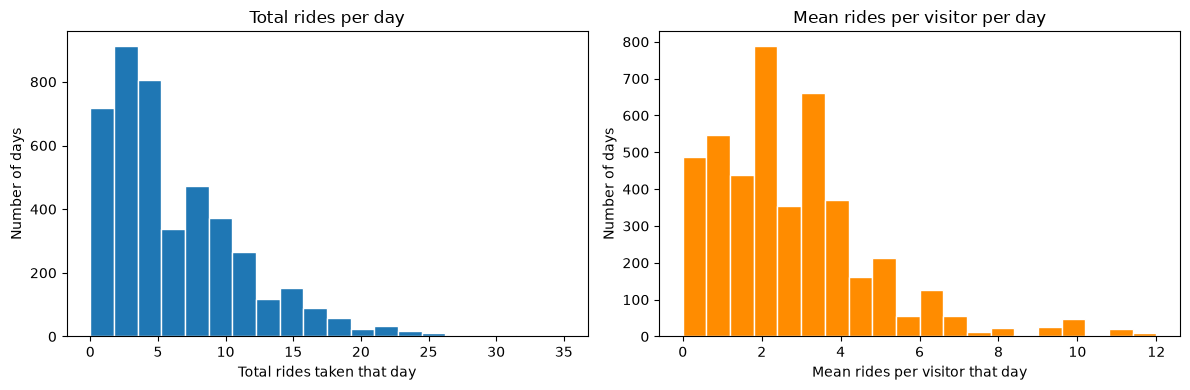

In [25]:
df["TotalRides"] = df[rides].sum(axis=1)

daily_total = df.groupby("VisitDate")["TotalRides"].sum()
daily_avg = df.groupby("VisitDate")["TotalRides"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

daily_total.plot.hist(ax=axes[0], bins=20, edgecolor="white")
axes[0].set_title("Total rides per day")
axes[0].set_xlabel("Total rides taken that day")
axes[0].set_ylabel("Number of days")

daily_avg.plot.hist(ax=axes[1], bins=20, edgecolor="white", color="darkorange")
axes[1].set_title("Mean rides per visitor per day")
axes[1].set_xlabel("Mean rides per visitor that day")
axes[1].set_ylabel("Number of days")

plt.tight_layout()
plt.show()

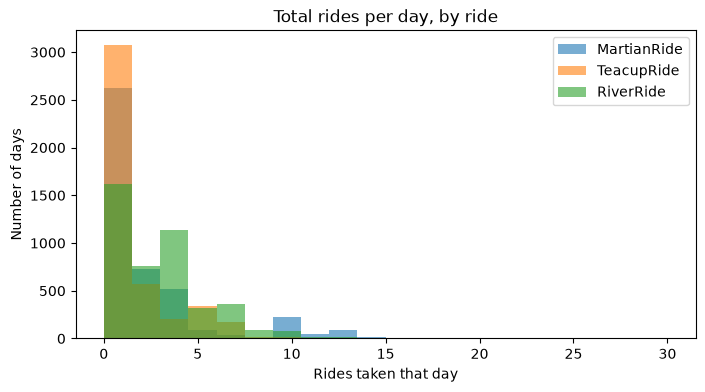

In [26]:
# The same idea for each ride separately (total per day)
df.groupby("VisitDate")[rides].sum().plot.hist(bins=20, alpha=0.6, figsize=(8, 4))
plt.title("Total rides per day, by ride")
plt.xlabel("Rides taken that day")
plt.ylabel("Number of days")
plt.show()

### 3.6 Bar chart of the total number of Adult and Child participants

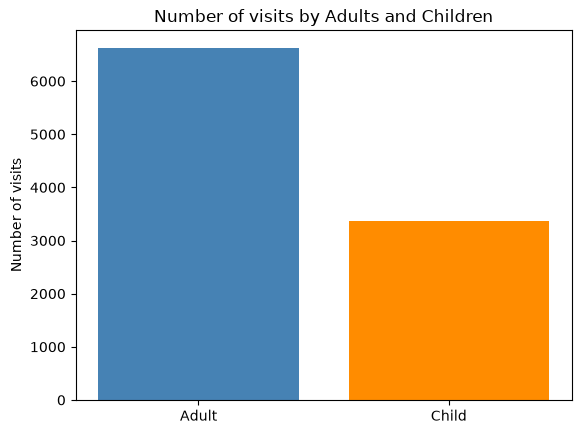

IsAdult
Adult    6625
Child    3375
Name: count, dtype: int64

In [27]:
counts = df["IsAdult"].value_counts().rename({True: "Adult", False: "Child"})

plt.bar(counts.index, counts.values, color=["steelblue", "darkorange"])
plt.title("Number of visits by Adults and Children")
plt.ylabel("Number of visits")
plt.show()

counts

### 3.7 Stacked bar chart of River Ride counts for Adults and Children
We one-hot encode `IsAdult` with `pd.get_dummies`, rename the columns, attach them with `join`, and then `groupby` the `RiverRide` value.

In [28]:
dummies = pd.get_dummies(df["IsAdult"]).rename(columns={True: "Adult", False: "Child"})
river = df[["RiverRide"]].join(dummies).groupby("RiverRide")[["Adult", "Child"]].sum()
river

,Adult,Child
RiverRide,,
0,4118,0
1,1498,841
2,1009,844
3,0,798
4,0,892


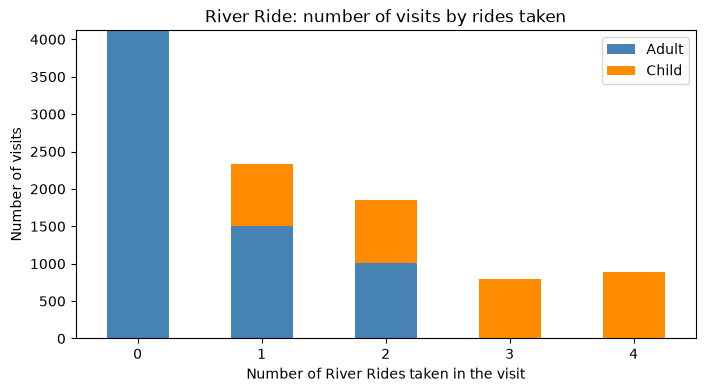

In [29]:
river.plot.bar(stacked=True, color=["steelblue", "darkorange"], figsize=(8, 4))
plt.title("River Ride: number of visits by rides taken")
plt.xlabel("Number of River Rides taken in the visit")
plt.ylabel("Number of visits")
plt.xticks(rotation=0)
plt.show()

*Alternative approach:* `pd.crosstab(df["RiverRide"], df["IsAdult"])` builds the same table in one line.

In [30]:
pd.crosstab(df["RiverRide"], df["IsAdult"]).rename(columns={True: "Adult", False: "Child"})

IsAdult,Child,Adult
RiverRide,,
0,0,4118
1,841,1498
2,844,1009
3,798,0
4,892,0


### Other tasks
Use seaborn to create a kernel density estimation (kde) plot, then a swarm plot, a violin plot, and a box plot. I chose `MoneySpent`, split by Adult and Child.

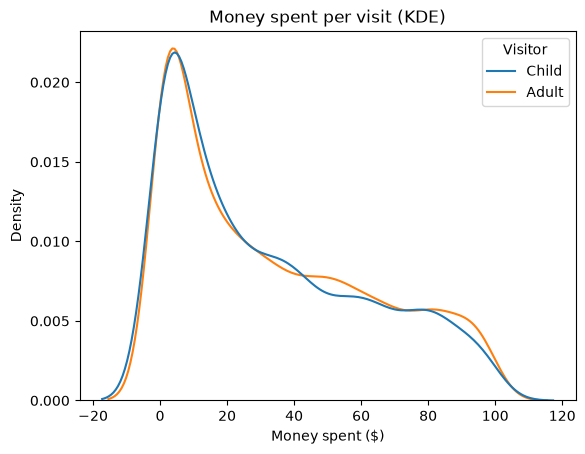

In [31]:
df["Visitor"] = df["IsAdult"].map({True: "Adult", False: "Child"})

sns.kdeplot(data=df, x="MoneySpent", hue="Visitor", common_norm=False)
plt.title("Money spent per visit (KDE)")
plt.xlabel("Money spent ($)")
plt.show()

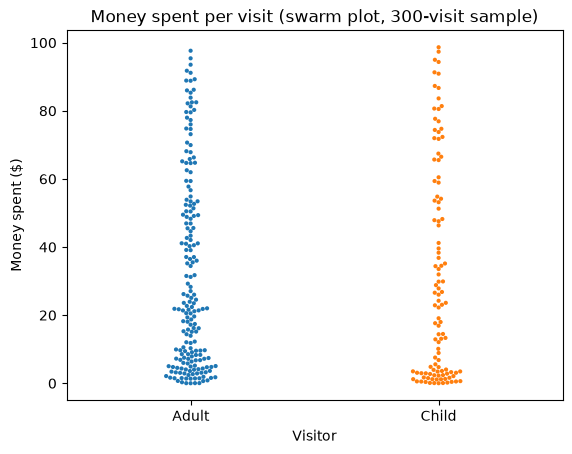

In [32]:
# A swarm plot of all 10,000 points is very slow and the points won't fit,
# so we use a random sample of 300 visits.
sample = df.sample(300, random_state=0)

sns.swarmplot(data=sample, x="Visitor", y="MoneySpent", hue="Visitor", size=3)
plt.title("Money spent per visit (swarm plot, 300-visit sample)")
plt.ylabel("Money spent ($)")
plt.show()

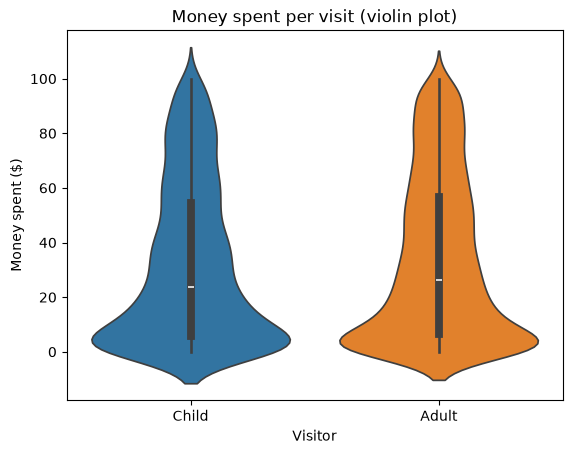

In [33]:
sns.violinplot(data=df, x="Visitor", y="MoneySpent", hue="Visitor")
plt.title("Money spent per visit (violin plot)")
plt.ylabel("Money spent ($)")
plt.show()

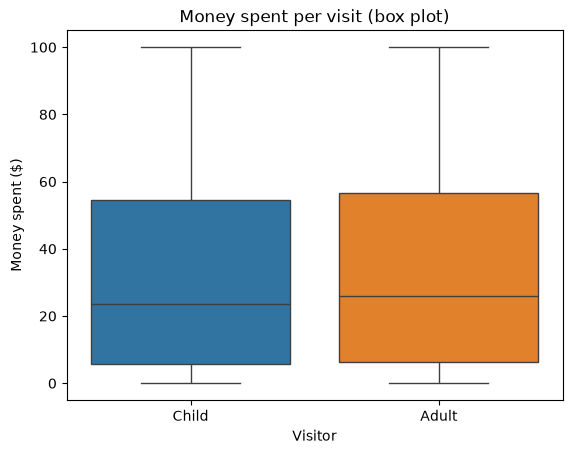

In [34]:
sns.boxplot(data=df, x="Visitor", y="MoneySpent", hue="Visitor")
plt.title("Money spent per visit (box plot)")
plt.ylabel("Money spent ($)")
plt.show()

**Which plots are best for showing this data?**

For `MoneySpent` (a continuous variable), the **violin plot** and **KDE plot** best show the shape: most visits spend a small amount, with a long tail toward $100, and adults and children look about the same. The **box plot** is best for quickly comparing medians and spread between the two groups, but it hides the shape. The **swarm plot** shows individual visits, which is nice for small samples but becomes unusable with 10,000 points, so it only works on a sample.

For the ride counts (small whole numbers like 0, 1, 2, 5), **bar charts** (like 3.7) are better than any of these, because KDE and violin plots smooth over values that can't actually happen (like 1.5 rides, or negative rides).

## 4. Storytelling With Data graph
A scatterplot similar to the one on page 45, with the Teacup Ride count and River Ride count as the two axes. We use only the first 100 visits.

Because the ride counts are whole numbers, many points land exactly on top of each other, so a small random "jitter" is added to spread them out. Adults (gray) never ride the Teacups, and Children (orange) always ride the River Ride at least once. A dashed line roughly separates the two groups, with a label written on it like "AVG" on page 45.

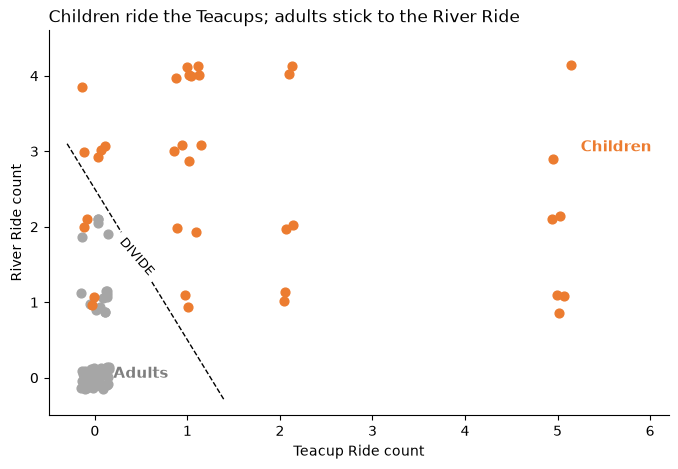

In [35]:
pts = df.iloc[0:100].copy()

rng = np.random.default_rng(0)
pts["x"] = pts["TeacupRide"] + rng.uniform(-0.15, 0.15, size=len(pts))
pts["y"] = pts["RiverRide"] + rng.uniform(-0.15, 0.15, size=len(pts))

adults = pts[pts["IsAdult"]]
children = pts[~pts["IsAdult"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(adults["x"], adults["y"], color="#A6A6A6", s=40, label="Adult")
ax.scatter(children["x"], children["y"], color="#EC7C30", s=40, label="Child")

# Dashed dividing line: River = 2.5 - 2 * Teacup
line_x = np.array([-0.3, 1.4])
ax.plot(line_x, 2.5 - 2 * line_x, linestyle="--", color="black", linewidth=1)
ax.text(0.45, 1.6, "DIVIDE", fontsize=9, color="black", rotation=-49,
        backgroundcolor="white", ha="center", va="center")

# Direct labels instead of a legend (a Storytelling With Data habit)
ax.text(0.2, 0.0, "Adults", color="#7F7F7F", fontsize=11, fontweight="bold")
ax.text(5.25, 3.0, "Children", color="#EC7C30", fontsize=11, fontweight="bold")

ax.set_title("Children ride the Teacups; adults stick to the River Ride", loc="left")
ax.set_xlabel("Teacup Ride count")
ax.set_ylabel("River Ride count")
ax.set_xlim(-0.5, 6.2)
ax.set_ylim(-0.5, 4.6)
ax.spines[["top", "right"]].set_visible(False)
plt.show()